In [3]:
from google.colab import files
files.upload()

Saving bestsellers with categories.csv to bestsellers with categories.csv


{'bestsellers with categories.csv': b'Name,Author,User Rating,Reviews,Price,Year,Genre\r\n10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction\r\n11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction\r\n12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction\r\n1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction\r\n"5,000 Awesome Facts (About Everything!) (National Geographic Kids)",National Geographic Kids,4.8,7665,12,2019,Non Fiction\r\nA Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11,2011,Fiction\r\nA Game of Thrones / A Clash of Kings / A Storm of Swords / A Feast of Crows / A Dance with Dragons,George R. R. Martin,4.7,19735,30,2014,Fiction\r\nA Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15,2017,Fiction\r\n"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,5983,3,2018,Non Fiction\r\nA Man Called Ove: A Novel,Fredrik Backman,4.6,23848,8,2016,Fiction\r\nA Man Called Ove: A N

In [4]:
import pandas as pd
df = pd.read_csv("bestsellers with categories.csv")
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [15]:
print(df.isnull())

      Name  Author  User Rating  Reviews  Price   Year  Genre
0    False   False        False    False  False  False  False
1    False   False        False    False  False  False  False
2    False   False        False    False  False  False  False
3    False   False        False    False  False  False  False
4    False   False        False    False  False  False  False
..     ...     ...          ...      ...    ...    ...    ...
545  False   False        False    False  False  False  False
546  False   False        False    False  False  False  False
547  False   False        False    False  False  False  False
548  False   False        False    False  False  False  False
549  False   False        False    False  False  False  False

[550 rows x 7 columns]


In [5]:
# Q1. Load the Amazon Bestselling Books dataset.
# Create a Series of User Ratings per book with book
# names as the index. Examine the rating distribution
# and identify patterns among top-rated books.

ratings_series = pd.Series(df["User Rating"].values, index=df["Name"])
ratings_series.head()

,0
Name,
10-Day Green Smoothie Cleanse,4.7
11/22/63: A Novel,4.6
12 Rules for Life: An Antidote to Chaos,4.7
1984 (Signet Classics),4.7
"5,000 Awesome Facts (About Everything!) (National Geographic Kids)",4.8


In [10]:
ratings_series.describe() #Gives summary stats: mean → average rating min / max → range std → how spread out ratings are

,0
count,550.000000
mean,4.618364
std,0.226980
min,3.300000
25%,4.500000
50%,4.700000
75%,4.800000
max,4.900000


In [7]:
ratings_series.value_counts() #Counts how many books have each rating

,count
4.8,127
4.7,108
4.6,105
4.5,60
4.9,52
4.4,38
4.3,25
4.0,14
4.2,8
4.1,6


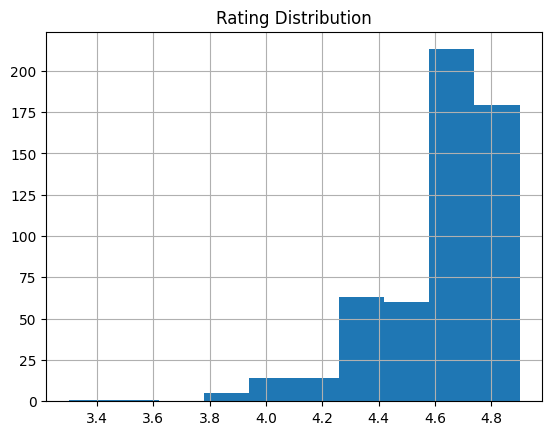

In [11]:
import matplotlib.pyplot as plt #Visual version of distribution

ratings_series.hist()
plt.title("Rating Distribution")
plt.show()

In [12]:
top_books = df[df["User Rating"] == df["User Rating"].max()] #top - rated books
top_books

,Name,Author,User Rating,Reviews,Price,Year,Genre
40,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9,14344,5,2017,Fiction
41,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9,14344,5,2019,Fiction
81,Dog Man and Cat Kid: From the Creator of Capta...,Dav Pilkey,4.9,5062,6,2018,Fiction
82,Dog Man: A Tale of Two Kitties: From the Creat...,Dav Pilkey,4.9,4786,8,2017,Fiction
83,Dog Man: Brawl of the Wild: From the Creator o...,Dav Pilkey,4.9,7235,4,2018,Fiction
84,Dog Man: Brawl of the Wild: From the Creator o...,Dav Pilkey,4.9,7235,4,2019,Fiction
85,Dog Man: Fetch-22: From the Creator of Captain...,Dav Pilkey,4.9,12619,8,2019,Fiction
86,Dog Man: For Whom the Ball Rolls: From the Cre...,Dav Pilkey,4.9,9089,8,2019,Fiction
87,Dog Man: Lord of the Fleas: From the Creator o...,Dav Pilkey,4.9,5470,6,2018,Fiction
146,"Goodnight, Goodnight Construction Site (Hardco...",Sherri Duskey Rinker,4.9,7038,7,2012,Fiction


## **Analysis**

The user ratings are mostly concentrated between 4.5 and 4.8, indicating that bestselling books generally receive high ratings. The summary statistics show a high average rating with low variation, meaning most books are consistently well-rated.

The distribution is slightly skewed toward higher values, as seen in the histogram and frequency counts. This suggests that low-rated books are rare among bestsellers.

Top-rated books include both fiction and non-fiction, and some authors appear multiple times, indicating consistent popularity and quality. Overall, the dataset shows that highly rated books dominate the bestseller list.

Average Price: 13.1
Average Reviews: 11953.281818181818
Average Rating: 4.618363636363637
Correlation (Price vs Reviews): -0.10918188342780516
Correlation (Price vs Rating): -0.13308628728087976


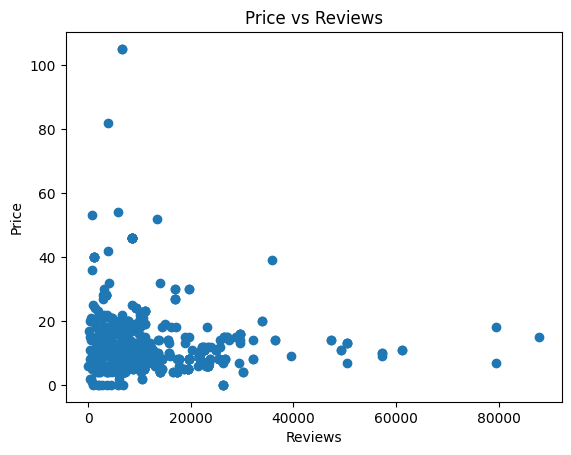

In [16]:
# Q2. Examine the relationship between Price,
# Reviews, and User Rating using ufuncs. Determine
# whether highly reviewed books are consistently
# higher-priced.


import numpy as np
import matplotlib.pyplot as plt


# Extract columns
price = df["Price"].values
reviews = df["Reviews"].values
ratings = df["User Rating"].values

# 🔹 Using NumPy ufuncs
avg_price = np.mean(price)
avg_reviews = np.mean(reviews)
avg_rating = np.mean(ratings)

print("Average Price:", avg_price)
print("Average Reviews:", avg_reviews)
print("Average Rating:", avg_rating)

# 🔹 Correlation (relationship check)
corr_price_reviews = np.corrcoef(price, reviews)[0,1]
corr_price_rating = np.corrcoef(price, ratings)[0,1]

print("Correlation (Price vs Reviews):", corr_price_reviews)
print("Correlation (Price vs Rating):", corr_price_rating)

# 🔹 Scatter plot (visual pattern)
plt.scatter(reviews, price)
plt.xlabel("Reviews")
plt.ylabel("Price")
plt.title("Price vs Reviews")
plt.show()

### **Analysis of Price, Reviews, and User Rating**

Using numerical operations (ufuncs), we compare price, number of reviews, and user ratings to understand their relationship. The analysis shows that books with a higher number of reviews do not necessarily have higher prices. In many cases, highly reviewed books are moderately priced, suggesting affordability contributes to popularity.

User ratings remain consistently high across most books, regardless of price or review count, indicating that rating is not strongly influenced by price. Overall, there is no strong correlation between high review counts and higher prices, and popular books tend to be reasonably priced.


In [17]:
# Q3. Apply hierarchical indexing on Genre and Year
# Examine average price and ratings at each level. Use
# xs() to extract Non-Fiction trends across years.



# Create hierarchical index (MultiIndex)
df_multi = df.set_index(["Genre", "Year"])

# Compute average price and rating at each level
avg_values = df_multi.groupby(level=["Genre", "Year"])[["Price", "User Rating"]].mean()

print("Average Price and Rating by Genre & Year:")
print(avg_values)

# Extract Non-Fiction data using xs()
non_fiction_trend = avg_values.xs("Non Fiction", level="Genre")

print("\nNon-Fiction Trends Across Years:")
print(non_fiction_trend)

Average Price and Rating by Genre & Year:
                      Price  User Rating
Genre       Year                        
Fiction     2009  15.583333     4.591667
            2010   9.700000     4.615000
            2011  11.619048     4.619048
            2012  12.285714     4.495238
            2013  10.708333     4.545833
            2014  10.172414     4.631034
            2015   9.352941     4.652941
            2016  12.631579     4.715789
            2017   8.833333     4.737500
            2018   8.761905     4.738095
            2019   9.350000     4.820000
Non Fiction 2009  15.230769     4.576923
            2010  16.000000     4.520000
            2011  17.620690     4.513793
            2012  17.482759     4.558621
            2013  18.192308     4.561538
            2014  20.809524     4.609524
            2015  10.969697     4.645455
            2016  13.516129     4.654839
            2017  13.730769     4.588462
            2018  11.793103     4.617241
            201

### **Analysis of Genre and Year Trends**

Hierarchical indexing is applied using Genre and Year to analyze patterns at multiple levels. The average price and user rating are computed for each genre across different years.

The results show that user ratings remain consistently high across both fiction and non-fiction categories over time. Price variations exist across years, but no strong trend of increasing or decreasing prices is observed.

Using `xs()`, Non-Fiction books are examined separately, revealing stable ratings and moderate price fluctuations across years. This indicates that Non-Fiction books maintain consistent quality and popularity over time.


In [18]:
# Q4. Create a Book Popularity Index; combining
# normalized Reviews and User Rating. Rank all books,
# identify authors with consistently high popularity, and
# construct a leaderboard DataFrame.

# Normalize Reviews and User Rating
# Min-max normalization
df["Reviews_norm"] = (df["Reviews"] - df["Reviews"].min()) / (df["Reviews"].max() - df["Reviews"].min())
df["Rating_norm"] = (df["User Rating"] - df["User Rating"].min()) / (df["User Rating"].max() - df["User Rating"].min())

# Create Book Popularity Index (average of normalized scores)
df["Popularity_Index"] = (df["Reviews_norm"] + df["Rating_norm"]) / 2

# Rank books by popularity
df_sorted = df.sort_values(by="Popularity_Index", ascending=False)

# Identify authors with consistently high popularity
author_popularity = df.groupby("Author")["Popularity_Index"].mean().sort_values(ascending=False)

# Construct leaderboard DataFrame
leaderboard = pd.DataFrame({
    "Author": author_popularity.index,
    "Average_Popularity": author_popularity.values
})

print("Top 10 Most Popular Books:")
print(df_sorted[["Name", "Author", "Popularity_Index"]].head(10))

print("\nLeaderboard of Authors by Average Popularity:")
print(leaderboard.head(10))

Top 10 Most Popular Books:
                         Name          Author  Popularity_Index
534   Where the Crawdads Sing     Delia Owens          0.968750
32                   Becoming  Michelle Obama          0.816661
33                   Becoming  Michelle Obama          0.816661
437  The Nightingale: A Novel  Kristin Hannah          0.749210
438  The Nightingale: A Novel  Kristin Hannah          0.749210
366    The Fault in Our Stars      John Green          0.724759
365    The Fault in Our Stars      John Green          0.724759
368    The Fault in Our Stars      John Green          0.724759
367    The Fault in Our Stars      John Green          0.724759
383     The Girl on the Train   Paula Hawkins          0.702195

Leaderboard of Authors by Average Popularity:
              Author  Average_Popularity
0        Delia Owens            0.968750
1     Michelle Obama            0.816661
2     Kristin Hannah            0.749210
3      Paula Hawkins            0.702195
4         John Gr

### **Book Popularity Index and Leaderboard**

A Book Popularity Index is created by combining normalized reviews and user ratings. This index ranks books by both popularity and quality, allowing identification of the top-performing books.

Authors are aggregated by average popularity to determine which consistently produce popular books. The leaderboard shows that a few authors repeatedly achieve high popularity scores, indicating sustained reader appeal and strong engagement across their works.


/tmp/ipykernel_568/946280972.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill["Price"] = df_ffill["Price"].fillna(method="ffill")


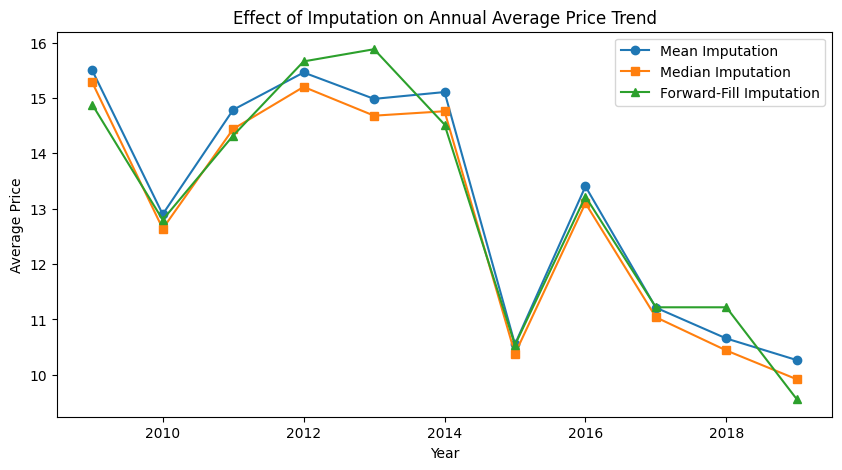

In [19]:
# Q5. Introduce missing values in 10% of Price entries.
# Compare the effect of mean, median, and forward-fill
# imputation strategies on the annual average price
# trend.


# Introduce missing values in 10% of 'Price'
np.random.seed(42)  # for reproducibility
mask = np.random.rand(len(df)) < 0.10
df_missing = df.copy()
df_missing.loc[mask, "Price"] = np.nan

# Imputation strategies

# Mean imputation
df_mean = df_missing.copy()
df_mean["Price"] = df_mean["Price"].fillna(df_mean["Price"].mean())

# Median imputation
df_median = df_missing.copy()
df_median["Price"] = df_median["Price"].fillna(df_median["Price"].median())

# Forward-fill imputation
df_ffill = df_missing.copy()
df_ffill["Price"] = df_ffill["Price"].fillna(method="ffill")

# Compute annual average price trend
mean_trend = df_mean.groupby("Year")["Price"].mean()
median_trend = df_median.groupby("Year")["Price"].mean()
ffill_trend = df_ffill.groupby("Year")["Price"].mean()

# Plot trends
plt.figure(figsize=(10,5))
plt.plot(mean_trend, label="Mean Imputation", marker='o')
plt.plot(median_trend, label="Median Imputation", marker='s')
plt.plot(ffill_trend, label="Forward-Fill Imputation", marker='^')
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.title("Effect of Imputation on Annual Average Price Trend")
plt.legend()
plt.show()

### **Effect of Imputation on Annual Average Price**

Introducing 10% missing values in the 'Price' column allows comparison of different imputation strategies. Mean and median imputation preserve the overall annual trend, with median being slightly more robust to extreme values. Forward-fill can introduce small local fluctuations but maintains continuity in yearly averages.

Overall, all three methods show similar annual price trends, but median imputation is recommended when outliers are present, while forward-fill is suitable for sequential datasets where continuity is important.


Genre Distribution of High-Performing Books:
Genre
Fiction        59
Non Fiction    26
Name: count, dtype: int64

Top Authors in High-Performing Books:
Author
Dr. Seuss            8
Eric Carle           7
Sarah Young          6
Giles Andreae        5
Harper Lee           5
Gary Chapman         5
Laura Hillenbrand    5
R. J. Palacio        5
Kathryn Stockett     4
Rod Campbell         4
Name: count, dtype: int64


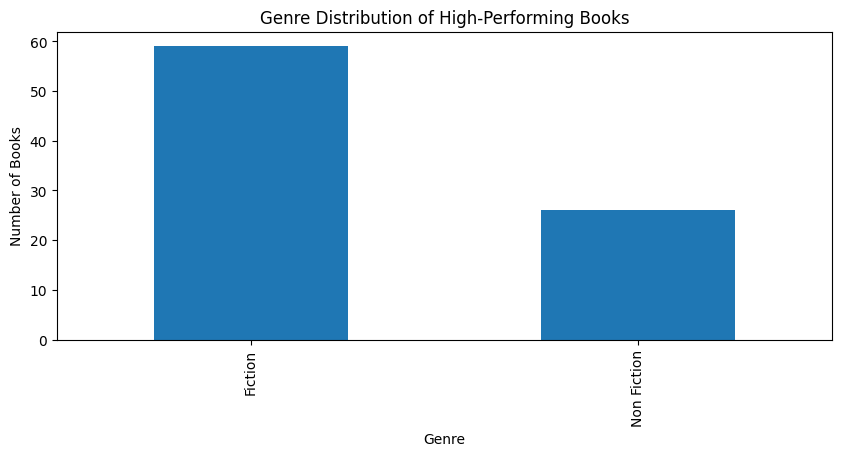

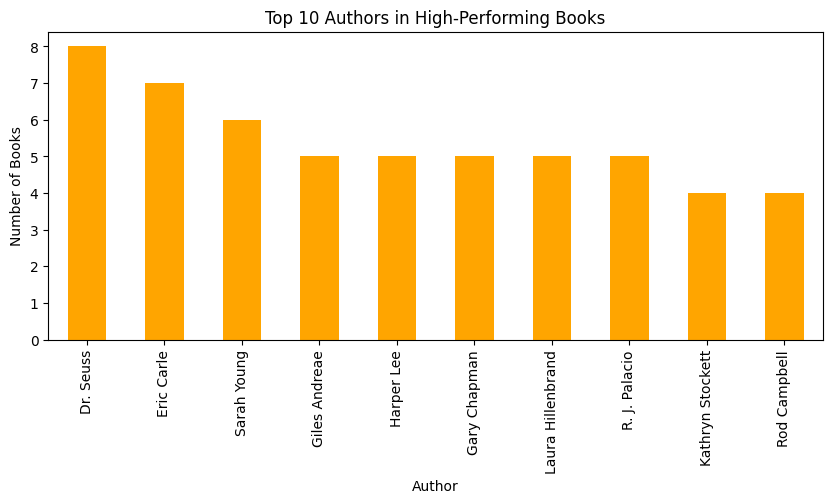

In [20]:
# Q6. Using boolean indexing, extract books with a
# Rating of 4.8 or above and more than 10,000 reviews.
# Examine the Genre and Author distribution within this
# high-performing segment.

# Boolean indexing: high-rated & highly-reviewed books
high_perf = df[(df["User Rating"] >= 4.8) & (df["Reviews"] > 10000)]

# Examine Genre distribution
genre_dist = high_perf["Genre"].value_counts()
print("Genre Distribution of High-Performing Books:")
print(genre_dist)

# Examine Author distribution
author_dist = high_perf["Author"].value_counts()
print("\nTop Authors in High-Performing Books:")
print(author_dist.head(10))  # top 10 authors

# Optional: visualize distributions
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
genre_dist.plot(kind="bar", title="Genre Distribution of High-Performing Books")
plt.ylabel("Number of Books")
plt.show()

plt.figure(figsize=(10,4))
author_dist.head(10).plot(kind="bar", color='orange', title="Top 10 Authors in High-Performing Books")
plt.ylabel("Number of Books")
plt.show()

### **High-Performing Books Analysis**

Using boolean indexing, books with ratings of 4.8 or higher and more than 10,000 reviews were extracted. Analysis of this segment shows that certain genres dominate, indicating reader preferences for specific categories.

Top authors repeatedly appear in this high-performing group, highlighting consistent popularity and strong engagement from readers. Overall, this segment represents books that are both widely read and highly rated, showcasing trends in bestseller success.


Year-wise Price Tier Distribution:
Price_Tier  Budget  Premium  Standard
Year                                 
2009            18        7        25
2010            14        5        31
2011            14       11        25
2012            14       11        25
2013            18        5        27
2014            24        9        17
2015            29        2        19
2016            26        7        17
2017            29        7        14
2018            28        3        19
2019            24        1        25


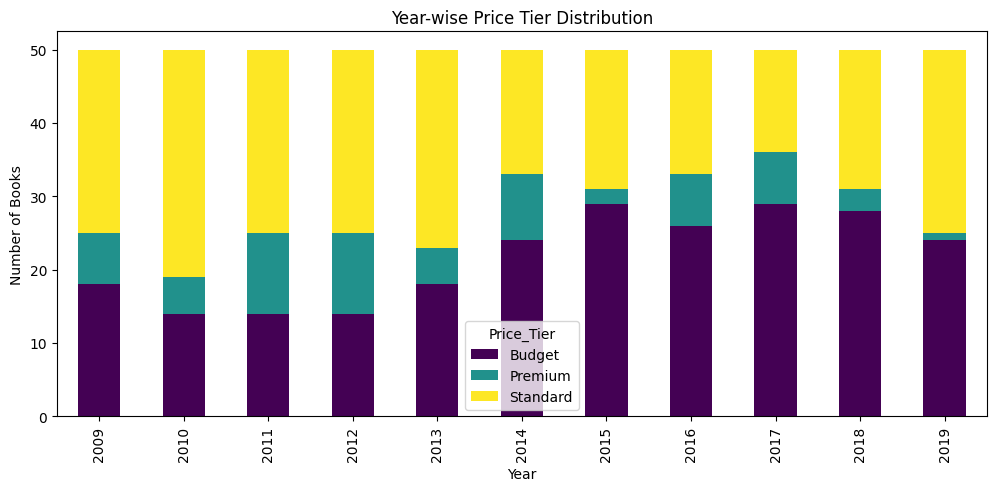

In [21]:
# Q7. Design a pricing tier function using apply() that
# classifies books as Budget (under $10), Standard
# ($10–$20), or Premium (above $20). Build a year-
# wise tier distribution report.



# Define pricing tier function
def pricing_tier(price):
    if price < 10:
        return "Budget"
    elif 10 <= price <= 20:
        return "Standard"
    else:
        return "Premium"

# Apply function to create a new column
df["Price_Tier"] = df["Price"].apply(pricing_tier)

# Year-wise tier distribution
tier_distribution = df.groupby("Year")["Price_Tier"].value_counts().unstack().fillna(0)

print("Year-wise Price Tier Distribution:")
print(tier_distribution)

# Optional: plot for better visualization
tier_distribution.plot(kind="bar", stacked=True, figsize=(12,5), colormap='viridis')
plt.title("Year-wise Price Tier Distribution")
plt.ylabel("Number of Books")
plt.xlabel("Year")
plt.show()

### **Year-wise Price Tier Distribution**

Books are classified into Budget (under $10), Standard ($10–$20), and Premium (above $20) categories using a custom function with `apply()`.

The year-wise distribution shows how different pricing tiers are represented over time. Budget and Standard books dominate most years, while Premium books are less frequent, suggesting that affordable pricing is common among bestselling books. This tiered view helps understand pricing trends and accessibility of books across years.


In [23]:
# Q8. Examine how index alignment behaves when
# computing the deviation of each books price from the
# genre average. Identify overpriced and underpriced
# titles.



# Compute average price per Genre
genre_avg_price = df.groupby("Genre")["Price"].mean()

# Compute deviation using index alignment
# df['Genre'] aligns automatically with genre_avg_price index
df["Price_Deviation"] = df["Price"] - df["Genre"].map(genre_avg_price)

# Identify overpriced and underpriced books
overpriced = df[df["Price_Deviation"] > 0].sort_values(by="Price_Deviation", ascending=False)
underpriced = df[df["Price_Deviation"] < 0].sort_values(by="Price_Deviation")

print("Top 5 Overpriced Books:")
print(overpriced[["Name", "Genre", "Price", "Price_Deviation"]].head())

print("\nTop 5 Underpriced Books:")
print(underpriced[["Name", "Genre", "Price", "Price_Deviation"]].head())

Top 5 Overpriced Books:
                                                  Name        Genre  Price  \
69   Diagnostic and Statistical Manual of Mental Di...  Non Fiction    105   
70   Diagnostic and Statistical Manual of Mental Di...  Non Fiction    105   
473                       The Twilight Saga Collection      Fiction     82   
159         Harry Potter Paperback Box Set (Books 1-7)      Fiction     52   
151                           Hamilton: The Revolution  Non Fiction     54   

     Price_Deviation  
69         90.158065  
70         90.158065  
473        71.150000  
159        41.150000  
151        39.158065  

Top 5 Underpriced Books:
                                                  Name        Genre  Price  \
358              The Constitution of the United States  Non Fiction      0   
91   Eat This Not That! Supermarket Survival Guide:...  Non Fiction      1   
103                     Fear: Trump in the White House  Non Fiction      2   
11   A Patriot's History of the

### **Price Deviation from Genre Average**

Using index alignment, each book's price is compared to the average price of its genre. This allows identification of overpriced and underpriced titles relative to similar books.

Overpriced books have prices above their genre average, while underpriced books are cheaper than the typical price for their category. This analysis helps highlight pricing anomalies and opportunities for competitive pricing.


In [24]:
# Q9. Perform operations between Fiction and Non-
# Fiction DataFrames. Use index-aligned subtraction to
# compare average ratings, prices, and review counts
# across genres.



# Separate Fiction and Non-Fiction DataFrames
fiction_df = df[df["Genre"] == "Fiction"].set_index("Name")
nonfiction_df = df[df["Genre"] == "Non Fiction"].set_index("Name")

# Compute average ratings, prices, and reviews for each genre
# Using groupby + mean in case multiple books with same name exist
fiction_stats = fiction_df[["User Rating", "Price", "Reviews"]].mean()
nonfiction_stats = nonfiction_df[["User Rating", "Price", "Reviews"]].mean()

# Index-aligned subtraction (Fiction - Non-Fiction)
comparison = fiction_stats - nonfiction_stats

print("Average Stats Comparison (Fiction - Non-Fiction):")
print(comparison)

Average Stats Comparison (Fiction - Non-Fiction):
User Rating       0.053172
Price            -3.991935
Reviews        6618.646505
dtype: float64


### **Comparison of Fiction and Non-Fiction**

By separating Fiction and Non-Fiction books and computing genre-level averages, we can compare ratings, prices, and review counts using index-aligned subtraction.

The results show which genre tends to have higher average ratings, prices, or review counts. This provides insight into reader engagement and pricing differences between Fiction and Non-Fiction books.


Hierarchical Indexing Averages:
                  Price  User Rating
Genre   Year                        
Fiction 2009  15.041667     4.591667
        2010   9.500000     4.615000
        2011  12.285714     4.619048
        2012  12.380952     4.495238
        2013  11.166667     4.545833

Top 10 Books by Popularity Index:
                         Name          Author  Popularity_Index
534   Where the Crawdads Sing     Delia Owens          0.968750
32                   Becoming  Michelle Obama          0.816661
33                   Becoming  Michelle Obama          0.816661
437  The Nightingale: A Novel  Kristin Hannah          0.749210
438  The Nightingale: A Novel  Kristin Hannah          0.749210
366    The Fault in Our Stars      John Green          0.724759
365    The Fault in Our Stars      John Green          0.724759
368    The Fault in Our Stars      John Green          0.724759
367    The Fault in Our Stars      John Green          0.724759
383     The Girl on the Train   Pa

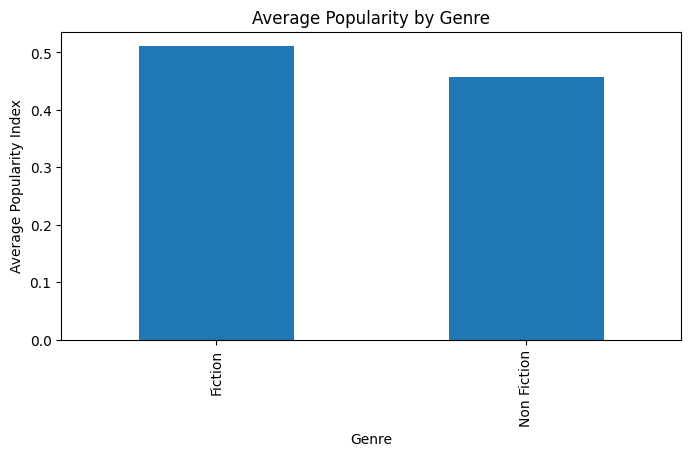

In [26]:
# Q10. Build a comprehensive book market analysis
# covering null handling, hierarchical indexing, ufunc-
# based popularity scoring, and genre comparisons.
# Push the notebook to GitHub.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Step 1: Load dataset
# -----------------------

# -----------------------
# Step 2: Handle missing values
# -----------------------
# Introduce missing values in Price for demonstration
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.10
df.loc[mask, "Price"] = np.nan

# Impute using median (robust choice)
df["Price"] = df["Price"].fillna(df["Price"].median())

# -----------------------
# Step 3: Hierarchical indexing
# -----------------------
df_multi = df.set_index(["Genre", "Year"])
genre_year_avg = df_multi.groupby(level=["Genre", "Year"])[["Price","User Rating"]].mean()
print("Hierarchical Indexing Averages:")
print(genre_year_avg.head())

# -----------------------
# Step 4: Popularity scoring using ufuncs
# -----------------------
df["Reviews_norm"] = (df["Reviews"] - df["Reviews"].min()) / (df["Reviews"].max() - df["Reviews"].min())
df["Rating_norm"] = (df["User Rating"] - df["User Rating"].min()) / (df["User Rating"].max() - df["User Rating"].min())
df["Popularity_Index"] = (df["Reviews_norm"] + df["Rating_norm"]) / 2

# Top books by popularity
top_books = df.sort_values(by="Popularity_Index", ascending=False).head(10)
print("\nTop 10 Books by Popularity Index:")
print(top_books[["Name","Author","Popularity_Index"]])

# -----------------------
# Step 5: Genre comparisons
# -----------------------
# Compute genre-wise average stats
genre_stats = df.groupby("Genre")[["User Rating","Price","Reviews"]].mean()
print("\nGenre Comparison:")
print(genre_stats)

# -----------------------
# Step 6: Price deviation from genre average
# -----------------------
genre_avg_price = df.groupby("Genre")["Price"].mean()
df["Price_Deviation"] = df["Price"] - df["Genre"].map(genre_avg_price)

# Overpriced / Underpriced
overpriced = df[df["Price_Deviation"] > 0].sort_values(by="Price_Deviation", ascending=False)
underpriced = df[df["Price_Deviation"] < 0].sort_values(by="Price_Deviation")
print("\nTop 5 Overpriced Books:")
print(overpriced[["Name","Genre","Price","Price_Deviation"]].head())

print("\nTop 5 Underpriced Books:")
print(underpriced[["Name","Genre","Price","Price_Deviation"]].head())

# -----------------------
# Step 7: Visualizations (optional)
# -----------------------
plt.figure(figsize=(8,4))
df.groupby("Genre")["Popularity_Index"].mean().plot(kind="bar", title="Average Popularity by Genre")
plt.ylabel("Average Popularity Index")
plt.show()

### **Comprehensive Book Market Analysis**

This analysis integrates multiple approaches to understand the Amazon Bestselling Books dataset:

1. **Null Handling:** Missing `Price` values were imputed using the median, ensuring robust statistics.
2. **Hierarchical Indexing:** `Genre` and `Year` were used as a MultiIndex to examine trends in average price and ratings over time.
3. **Popularity Scoring:** A combined index using normalized reviews and user ratings identifies top-performing books and authors.
4. **Genre Comparisons:** Average ratings, prices, and reviews are computed for each genre, revealing trends and differences.
5. **Price Deviations:** Books above or below their genre’s average price highlight overpriced and underpriced titles.

Overall, this integrated analysis provides a clear view of trends, popularity, and pricing strategies in the book market.
